In [1]:
# === SESSION BOOTSTRAP ===
from google.colab import drive
drive.mount('/content/drive')
import os, subprocess, sys
PARENT="/content/drive/MyDrive/UAV_TRUST_Research"; REPO=f"{PARENT}/uav-trust-research"
for fn in (".gitconfig",".git-credentials"):
    p=os.path.join(PARENT,fn)
    if os.path.exists(p): subprocess.run(f'cp "{p}" /root/{fn}',shell=True)
subprocess.run("git config --global credential.helper store",shell=True)
if os.path.isdir(REPO):
    os.chdir(REPO); sys.path.insert(0,REPO) if REPO not in sys.path else None; print("cwd:",os.getcwd())
else: print("run 00_setup first")

Mounted at /content/drive
cwd: /content/drive/MyDrive/UAV_TRUST_Research/uav-trust-research


In [2]:
!pip install xgboost scikit-learn matplotlib pandas numpy scipy pyarrow requests --quiet

In [3]:
# Sequential monitoring: does conformal coverage alarm EARLIER in time than an error-rate alarm
# when an unseen attack family enters a stream? Built for BOTH a sharp switch and a gradual ramp.
DATASETS=[
 {"name":"UAVIDS-2025","kind":"zenodo","record":"15336998","data_dir":"data/uavids2025",
  "label_col":"label","normal_value":"Normal Traffic","include_families":None,"subsample_n":None,
  "drops":["unnamed","flowid","srcaddr","dstaddr","srcport","dstport","index","timestamp"]},
 {"name":"UAV-NIDD","kind":"file","file":"data/uav_nidd/UAV-NDD CSV/UAV-Case1-Label.csv",
  "parquet":"data/uav_nidd/case1.parquet","data_dir":"data/uav_nidd","label_col":"Label",
  "normal_value":"Normal","include_families":["DDoS","UDP Flooding","MITM","Jamming","BruteForce","De-authentication"],
  "subsample_n":200000,
  "drops":["unnamed","index","ip.src","ip.dst","ip.proto","wlan.tag","srcport","dstport","udp.srcport","udp.dstport",
           "frame.time","frame.number","time_epoch","time_relative","time_delta","bssid","mactime",
           "vendor_oui","wlan_radio.timestamp","wlan_radio.start_tsf","radiotap.timestamp","wlan.seq"]},
]
CFG={"seeds":list(range(8)),"alpha":0.10,
     "normal_fracs":{"train":0.60,"cal":0.20,"test_seen":0.10,"test_shift":0.10},
     "family_fracs":{"train":0.60,"cal":0.20,"test_seen":0.20},
     "xgb":{"n_estimators":300,"max_depth":6,"learning_rate":0.1,"subsample":0.9,"colsample_bytree":0.9,"tree_method":"hist"},
     # --- stream design (shared, fixed, never tuned to outcome) ---
     "window":200,          # sliding-window size for BOTH monitors
     "burn_in":3000,        # seen-only prefix used to CALIBRATE both alarm thresholds
     "post_len":4000,       # stream length after the changepoint
     "ramp_len":2000,       # for the gradual condition: unseen fraction rises 0->1 over this many steps
     "alarm_pct":95,        # both thresholds = this percentile on burn-in (fair comparison)
     "persistence":3,       # alarm must hold this many consecutive windows (debounce)
     "fig_dir":"figures","report_dir":"reports"}
for d in [CFG["fig_dir"],CFG["report_dir"]]: os.makedirs(d,exist_ok=True)
print("configured")

configured


In [4]:
import numpy as np, pandas as pd, requests, glob, zipfile, importlib, gc, src.data
importlib.reload(src.data)
import matplotlib.pyplot as plt, xgboost as xgb
from src.data import load_csvs, detect_schema, prepare_splits
from src.trust import conformal_qhat

def load_dataset(spec):
    dd=spec["data_dir"]; os.makedirs(dd,exist_ok=True)
    if spec["kind"]=="zenodo":
        if not glob.glob(dd+"/**/*.csv",recursive=True):
            meta=requests.get(f"https://zenodo.org/api/records/{spec['record']}",timeout=60).json()
            for f in meta.get("files",[]):
                n,u=f["key"],f["links"]["self"]
                if n.lower().endswith((".csv",".zip",".gz")): open(os.path.join(dd,n),"wb").write(requests.get(u,timeout=1200).content)
            for z in glob.glob(dd+"/*.zip"): zipfile.ZipFile(z).extractall(dd)
        df=load_csvs(dd); lc,nv,fams=detect_schema(df,spec["label_col"],spec["normal_value"])
    else:
        pq=spec.get("parquet")
        df=pd.read_parquet(pq) if pq and os.path.exists(pq) else pd.read_csv(spec["file"],low_memory=False,encoding="latin-1")
        lc,nv=spec["label_col"],spec["normal_value"]; fams=[v for v in df[lc].unique() if v!=nv]
    if spec.get("subsample_n") and len(df)>spec["subsample_n"]:
        df=df.groupby(lc,group_keys=False).sample(frac=spec["subsample_n"]/len(df),random_state=42).reset_index(drop=True)
    if spec.get("include_families"):
        df=df[df[lc].isin([nv]+list(spec["include_families"]))].reset_index(drop=True); fams=list(spec["include_families"])
    return df,lc,nv,fams

def first_alarm(signal, thr, above, persistence):
    """First index where signal crosses thr (above/below) for `persistence` consecutive steps."""
    cond = (signal>thr) if above else (signal<thr)
    run=0
    for i,c in enumerate(cond):
        run = run+1 if c else 0
        if run>=persistence: return i-persistence+1
    return None   # never alarmed
print("helpers ready")

helpers ready


In [5]:
# Build one stream and run BOTH monitors. Returns alarm steps (relative to changepoint) for coverage & error.
def run_stream(pool_seen_normal, pool_seen_atk, pool_unseen, p_of, qhat, rng, mode):
    W,BI,PL,RL=CFG["window"],CFG["burn_in"],CFG["post_len"],CFG["ramp_len"]
    def draw(pool,n): return pool[rng.integers(0,len(pool),size=n)]
    # burn-in: seen normal + seen attacks (mix ~ 50/50), used to calibrate thresholds
    bi = np.concatenate([draw(pool_seen_normal,BI//2), draw(pool_seen_atk,BI-BI//2)])
    rng.shuffle(bi)
    # post-changepoint: normal + (unseen replacing seen-attack, sharply or via ramp)
    post_rows=[]; post_isattack=[]
    for t in range(PL):
        if rng.random()<0.5:
            x=pool_seen_normal[rng.integers(0,len(pool_seen_normal))]; post_rows.append(x); post_isattack.append(0)
        else:
            frac = 1.0 if mode=="sharp" else min(1.0, t/max(1,RL))   # unseen share among attacks
            src = pool_unseen if rng.random()<frac else pool_seen_atk
            x=src[rng.integers(0,len(src))]; post_rows.append(x); post_isattack.append(1)
    stream = np.concatenate([bi, np.array(post_rows)]); is_atk=np.array([0]*BI+post_isattack)
    y_true = is_atk  # attack=1
    p = p_of(stream)                              # model attack-probability along the stream
    pred = (p>=0.5).astype(int)
    # per-step signals
    err_step = (pred!=y_true).astype(float)                       # error indicator
    inset_attack = ((1-p)<=qhat).astype(int); inset_normal=(p<=qhat).astype(int)
    covered = np.where(y_true==1, inset_attack, inset_normal).astype(float)  # conformal coverage indicator
    # sliding-window rates
    def roll(a):
        s=np.cumsum(np.insert(a,0,0)); return (s[W:]-s[:-W])/W
    err_rate = roll(err_step)                       # want alarm when this rises
    cov_rate = roll(covered)                        # want alarm when this FALLS below thr
    # thresholds calibrated on burn-in windows only (fair: same percentile for both)
    nb = BI - W  # number of burn-in windows
    err_thr = np.percentile(err_rate[:nb], CFG["alarm_pct"])
    cov_thr = np.percentile(cov_rate[:nb], 100-CFG["alarm_pct"])
    # first alarms measured AFTER changepoint (window index for changepoint = BI - W)
    cp = BI - W
    e_hit = first_alarm(err_rate[cp:], err_thr, True,  CFG["persistence"])
    c_hit = first_alarm(cov_rate[cp:], cov_thr, False, CFG["persistence"])
    return c_hit, e_hit
print("stream runner ready")

stream runner ready


In [6]:
# Main loop: per dataset x family x seed x mode -> alarm steps + lead time
rows=[]
for spec in DATASETS:
    df,lc,nv,fams=load_dataset(spec)
    print(spec["name"],"loaded",len(df))
    for F in fams:
        for seed in CFG["seeds"]:
            S=prepare_splits(df,lc,nv,F,spec["drops"],CFG["normal_fracs"],CFG["family_fracs"],seed)
            for k in ["X_train","X_cal","X_seen","X_shift"]: S[k]=S[k].astype(np.float32)
            clf=xgb.XGBClassifier(objective="binary:logistic",eval_metric="logloss",random_state=seed,**CFG["xgb"]).fit(S["X_train"],S["y_train"])
            # conformal threshold from a held-out calibration split (seen only)
            qhat=conformal_qhat(clf.predict_proba(S["X_cal"])[:,1], S["y_cal"], alpha=CFG["alpha"])
            p_of=lambda X: clf.predict_proba(X)[:,1]
            # pools
            seen_normal = S["X_seen"][S["fam_seen"]==nv]
            seen_atk    = S["X_seen"][S["fam_seen"]!=nv]
            unseen      = S["X_shift"][S["fam_shift"]==F]
            if len(seen_normal)<50 or len(seen_atk)<50 or len(unseen)<50:
                del S,clf; gc.collect(); continue
            for mode in ["sharp","gradual"]:
                rng=np.random.default_rng(1000*seed+ (0 if mode=="sharp" else 1))
                c_hit,e_hit=run_stream(seen_normal,seen_atk,unseen,p_of,qhat,rng,mode)
                lead = (e_hit - c_hit) if (c_hit is not None and e_hit is not None) else np.nan
                rows.append({"dataset":spec["name"],"held_out":str(F),"seed":seed,"mode":mode,
                             "cov_alarm":c_hit,"err_alarm":e_hit,
                             "cov_fired":c_hit is not None,"err_fired":e_hit is not None,"lead":lead})
            del S,clf; gc.collect()
        print(" ",spec["name"],F,"done")
    del df; gc.collect()
M=pd.DataFrame(rows); M.to_csv(os.path.join(CFG["report_dir"],"13_sequential_monitoring_raw.csv"),index=False)
print("runs:",len(M))

UAVIDS-2025 loaded 122171
  UAVIDS-2025 Sybil Attack done
  UAVIDS-2025 Blackhole Attack done
  UAVIDS-2025 Wormhole Attack done
  UAVIDS-2025 Flooding Attack done
UAV-NIDD loaded 168881
  UAV-NIDD DDoS done
  UAV-NIDD UDP Flooding done
  UAV-NIDD MITM done
  UAV-NIDD Jamming done
  UAV-NIDD BruteForce done
  UAV-NIDD De-authentication done
runs: 160


In [7]:
# HEADLINE: coverage-fires-first rate + lead-time distribution, per mode
def summarize(sub):
    both=sub[sub["cov_fired"]&sub["err_fired"]]
    cov_only=sub[sub["cov_fired"]&(~sub["err_fired"])]
    lead=both["lead"].dropna()
    return pd.Series({
        "runs":len(sub),
        "cov_fired_%":round(100*sub["cov_fired"].mean(),1),
        "err_fired_%":round(100*sub["err_fired"].mean(),1),
        "cov_only (err never fired) %":round(100*len(cov_only)/max(1,len(sub)),1),
        "coverage_leads_% (when both fire)":round(100*(lead>0).mean(),1) if len(lead) else float("nan"),
        "median_lead_steps":round(float(lead.median()),1) if len(lead) else float("nan"),
        "mean_lead_steps":round(float(lead.mean()),1) if len(lead) else float("nan")})
print("=== Sequential monitoring: does coverage alarm earlier than error? ===")
print(M.groupby("mode").apply(summarize).T.to_string())
print("\n--- per dataset x mode ---")
print(M.groupby(["dataset","mode"]).apply(summarize).T.to_string())
M.groupby(["dataset","mode"]).apply(summarize).T.to_csv(os.path.join(CFG["report_dir"],"13_lead_summary.csv"))

=== Sequential monitoring: does coverage alarm earlier than error? ===
mode                               gradual  sharp
runs                                  80.0   80.0
cov_fired_%                            7.5   13.8
err_fired_%                           15.0   12.5
cov_only (err never fired) %           5.0    8.8
coverage_leads_% (when both fire)      0.0    0.0
median_lead_steps                      0.0    0.0
mean_lead_steps                        0.0    0.0

--- per dataset x mode ---
dataset                           UAV-NIDD       UAVIDS-2025      
mode                               gradual sharp     gradual sharp
runs                                  48.0  48.0        32.0  32.0
cov_fired_%                            4.2  12.5        12.5  15.6
err_fired_%                           12.5  12.5        18.8  12.5
cov_only (err never fired) %           4.2  12.5         6.2   3.1
coverage_leads_% (when both fire)      NaN   NaN         0.0   0.0
median_lead_steps               

/tmp/ipykernel_613/3202061616.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(M.groupby("mode").apply(summarize).T.to_string())
/tmp/ipykernel_613/3202061616.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(M.groupby(["dataset","mode"]).apply(summarize).T.to_string())
/tmp/ipykernel_613/3202061616.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This b

In [8]:
# Per-family lead (positive = coverage earlier), both modes
tab=M[M["cov_fired"]&M["err_fired"]].groupby(["dataset","held_out","mode"])["lead"].median().unstack("mode").round(1)
tab["cov_only_sharp"]=M[(M["mode"]=="sharp")&(~M["err_fired"])&M["cov_fired"]].groupby(["dataset","held_out"]).size()
print("Median lead time in steps (positive = coverage alarms earlier); cov_only = runs where error never fired:")
print(tab.fillna("-").to_string())
tab.to_csv(os.path.join(CFG["report_dir"],"13_lead_by_family.csv"))

Median lead time in steps (positive = coverage alarms earlier); cov_only = runs where error never fired:
mode                         gradual  sharp cov_only_sharp
dataset     held_out                                      
UAVIDS-2025 Blackhole Attack       -    0.0              -
            Flooding Attack      0.0    0.0            1.0
            Sybil Attack         0.0    0.0              -
            Wormhole Attack        -    0.0              -


/tmp/ipykernel_613/2061489745.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  s=M.groupby("mode").apply(lambda d: 100*(d[d.cov_fired&d.err_fired]["lead"]>0).mean())


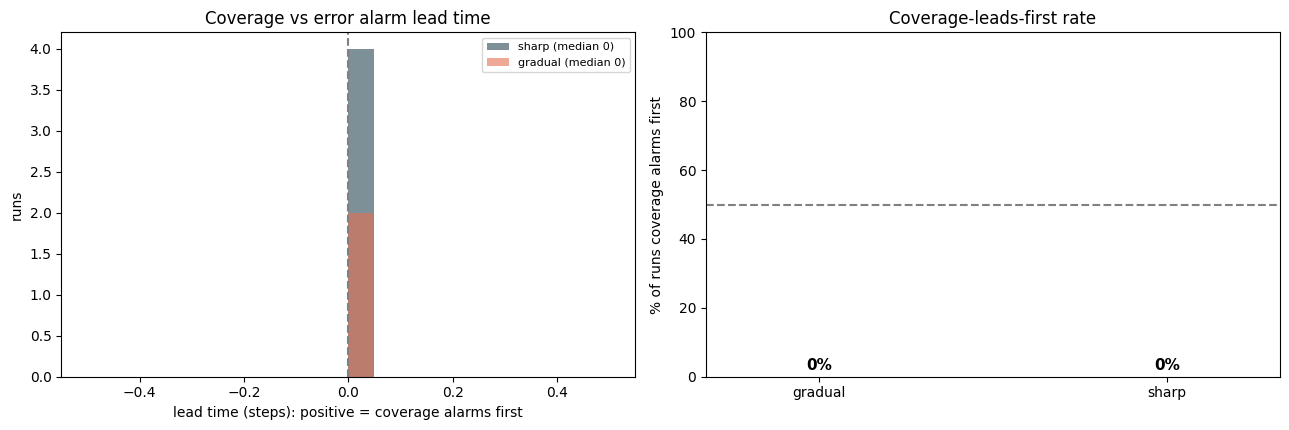

In [9]:
# FIGURE: lead-time distribution (both modes) + coverage-leads bar
fig,ax=plt.subplots(1,2,figsize=(13,4.4))
for mode,col in [("sharp","#264653"),("gradual","#e76f51")]:
    lead=M[(M["mode"]==mode)&M["cov_fired"]&M["err_fired"]]["lead"].dropna()
    if len(lead): ax[0].hist(lead,bins=20,alpha=0.6,label=f"{mode} (median {lead.median():.0f})",color=col)
ax[0].axvline(0,ls="--",color="gray"); ax[0].set_xlabel("lead time (steps): positive = coverage alarms first")
ax[0].set_ylabel("runs"); ax[0].set_title("Coverage vs error alarm lead time"); ax[0].legend(fontsize=8)
s=M.groupby("mode").apply(lambda d: 100*(d[d.cov_fired&d.err_fired]["lead"]>0).mean())
ax[1].bar(s.index,s.values,color=["#264653","#e76f51"],width=0.5)
ax[1].axhline(50,ls="--",color="gray"); ax[1].set_ylabel("% of runs coverage alarms first"); ax[1].set_ylim(0,100)
ax[1].set_title("Coverage-leads-first rate");
for i,v in enumerate(s.values): ax[1].text(i,v+2,f"{v:.0f}%",ha="center",fontsize=11,fontweight="bold")
fig.tight_layout(); fig.savefig(os.path.join(CFG["fig_dir"],"13_sequential_lead.png"),dpi=150,bbox_inches="tight"); plt.show()

In [ ]:
!git add reports/ figures/ notebooks/
!git commit -m "13 sequential monitoring: coverage vs error alarm lead time under sharp and gradual unseen-attack entry; tests the earliest-signal claim"
!git push origin main